In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import accuracy_score
from sklearn.neighbors import KernelDensity

from p6utils import KDEClassifier, plot_digits

## (a) Evaluación del Kernel Gaussiano: Bandwidth por Defecto vs Optimizado
Cargamos el conjunto de datos de dígitos (`load_digits`), dividimos en conjuntos de entrenamiento y prueba, y comparamos el desempeño del kernel Gaussiano utilizando el ancho de banda por defecto ($1.0$) frente al óptimo encontrado mediante validación cruzada (`GridSearchCV`).

In [6]:
digits = load_digits()
X, y = digits.data, digits.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

print(f"Dimensiones del dataset: {X.shape}")

# evalua con bandwidth por defecto
kde_gauss_default = KDEClassifier(bandwidth=1.0, kernel='gaussian')
kde_gauss_default.fit(X_train, y_train)
y_pred_default = kde_gauss_default.predict(X_test)
acc_default = accuracy_score(y_test, y_pred_default)
print(f"\n[Gaussian] Accuracy con bandwidth por defecto (1.0): {acc_default:.4f} ({acc_default*100:.2f}%)")

# busqueda del ancho de banda optimo con cross-validation
# Evaluamos un rango logarítmico amplio de parámetros para el ancho de banda
bandwidths = np.logspace(-1, 1.5, 30)
grid_gauss = GridSearchCV(KDEClassifier(kernel='gaussian'), {'bandwidth': bandwidths}, cv=5)
grid_gauss.fit(X_train, y_train)

best_bw_gauss = grid_gauss.best_params_['bandwidth']

# evaluacion
y_pred_opt = grid_gauss.predict(X_test)
acc_opt = accuracy_score(y_test, y_pred_opt)

print(f"[Gaussian] Ancho de banda óptimo (GridSearchCV): {best_bw_gauss:.4f}")
print(f"[Gaussian] Accuracy con bandwidth optimizado: {acc_opt:.4f} ({acc_opt*100:.2f}%)")

Dimensiones del dataset: (1797, 64)

[Gaussian] Accuracy con bandwidth por defecto (1.0): 0.5511 (55.11%)
[Gaussian] Ancho de banda óptimo (GridSearchCV): 4.3444
[Gaussian] Accuracy con bandwidth optimizado: 0.9889 (98.89%)


## (b) Evaluación de los Kernels Exponencial y Epanechnikov
Repetimos la metodología de optimización paramétrica empleando otros dos tipos de funciones kernel soportadas por `scikit-learn`: el kernel exponencial (`exponential`) y el kernel de Epanechnikov (`epanechnikov`), contrastando siempre sus métricas contra sus configuraciones por defecto.

In [7]:
kernel_list = ['exponential', 'epanechnikov']

for k in kernel_list:
    print(f"\nKernel: '{k.upper()}' ===")

    # modelo con bandwidth default
    model_default = KDEClassifier(bandwidth=1.0, kernel=k)
    model_default.fit(X_train, y_train)
    acc_k_default = accuracy_score(y_test, model_default.predict(X_test))
    print(f"[{k}] Accuracy con bandwidth 1.0: {acc_k_default:.4f}")

    # optimizacion de bandwidth
    grid_k = GridSearchCV(KDEClassifier(kernel=k), {'bandwidth': bandwidths}, cv=5)
    grid_k.fit(X_train, y_train)
    
    best_bw_k = grid_k.best_params_['bandwidth']
    acc_k_opt = accuracy_score(y_test, grid_k.predict(X_test))
    
    print(f"[{k}] Ancho de banda óptimo encontrado: {best_bw_k:.4f}")
    print(f"[{k}] Accuracy con bandwidth optimizado: {acc_k_opt:.4f} ({acc_k_opt*100:.2f}%)")


Kernel: 'EXPONENTIAL' ===
[exponential] Accuracy con bandwidth 1.0: 0.9889
[exponential] Ancho de banda óptimo encontrado: 0.8877
[exponential] Accuracy con bandwidth optimizado: 0.9889 (98.89%)

Kernel: 'EPANECHNIKOV' ===
[epanechnikov] Accuracy con bandwidth 1.0: 0.0978
[epanechnikov] Ancho de banda óptimo encontrado: 31.6228
[epanechnikov] Accuracy con bandwidth optimizado: 0.9756 (97.56%)


## Generación de Nuevos Dígitos a partir de KDE

Forma original de los datos: (1797, 64)
Forma proyectada (PCA): (1797, 15)
Ancho de banda óptimo para muestreo (PCA-15D): 3.2903

--- Visualizando Dígitos Originales (Selección aleatoria) ---


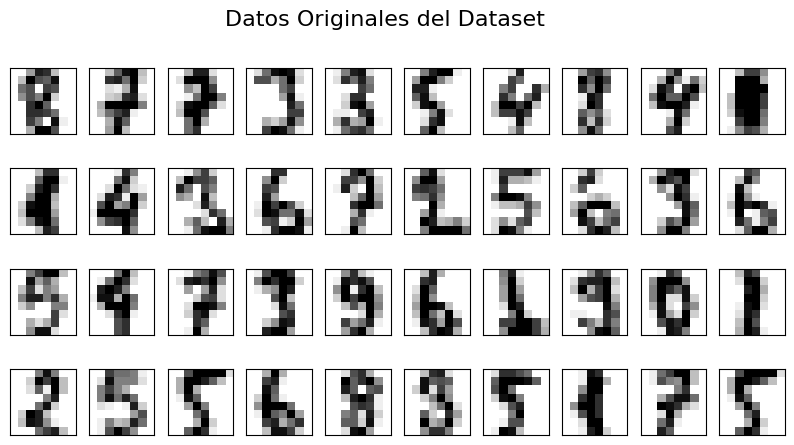


--- Visualizando NUEVOS Dígitos Generados por KDE + PCA ---


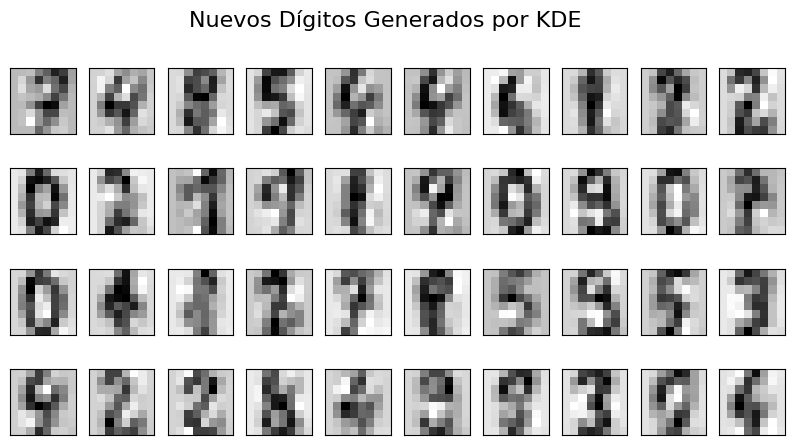

In [ ]:
# 1. Reducción de Dimensionalidad (PCA)
# Proyectamos las 64 características (píxeles) a 15 componentes principales,
# lo cual suele explicar la gran mayoría de la varianza en este dataset.
# Usamos 'whiten=False' (blanqueo desactivado) para preservar la escala relativa de los componentes para KDE.
pca = PCA(n_components=15, whiten=False)
X_pca = pca.fit_transform(digits.data) # Usamos los datos originales (no escalados) para una reconstrucción visual más fácil

# Visualizamos la reducción
print(f"Forma original de los datos: {digits.data.shape}")
print(f"Forma proyectada (PCA): {X_pca.shape}")

# 2. Búsqueda de ancho de banda óptimo en el subespacio 15D
# Usamos un rango diferente para el ancho de banda, adecuado para las amplitudes de los componentes de PCA
bandwidths = np.logspace(-1, 1, 30)
grid_sampling = GridSearchCV(KernelDensity(kernel='gaussian'), {'bandwidth': bandwidths}, cv=5)
grid_sampling.fit(X_pca)

best_bw_sampling = grid_sampling.best_params_['bandwidth']
print(f"Ancho de banda óptimo para muestreo (PCA-15D): {best_bw_sampling:.4f}")

# 3. Entrenamiento de KDE final en el subespacio PCA y generación
kde_sampling = KernelDensity(bandwidth=best_bw_sampling, kernel='gaussian')
kde_sampling.fit(X_pca)

# Generamos 40 muestras aleatorias del espacio PCA
n_samples = 40
new_data_pca = kde_sampling.sample(n_samples, random_state=42)

# 4. Transformación Inversa de PCA
# Recuperamos los 64 píxeles originales a partir de los componentes generados en 15D.
new_data = pca.inverse_transform(new_data_pca)

# 5. Visualización
# Mostramos primero los datos originales para comparar
print("\n--- Visualizando Dígitos Originales (Selección aleatoria) ---")
np.random.seed(0)
indices_orig = np.random.randint(0, digits.data.shape[0], size=40)
plot_digits(digits.data[indices_orig], titulo="Datos Originales del Dataset")
plt.show()

# Mostramos los datos generados
print("\n--- Visualizando NUEVOS Dígitos Generados por KDE + PCA ---")
plot_digits(new_data, titulo="Nuevos Dígitos Generados por KDE")
plt.show()